In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nelgiriyewithana_global_weather_repository_path = kagglehub.dataset_download('nelgiriyewithana/global-weather-repository')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-weather-repository/GlobalWeatherRepository.csv
/kaggle/input/global-weather-repository/state.db


In [ ]:
path  = "/kaggle/input/global-weather-repository/GlobalWeatherRepository.csv"
weather = pd.read_csv(path)

In [ ]:
weather.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48331 entries, 0 to 48330
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       48331 non-null  object 
 1   location_name                 48331 non-null  object 
 2   latitude                      48331 non-null  float64
 3   longitude                     48331 non-null  float64
 4   timezone                      48331 non-null  object 
 5   last_updated_epoch            48331 non-null  int64  
 6   last_updated                  48331 non-null  object 
 7   temperature_celsius           48331 non-null  float64
 8   temperature_fahrenheit        48331 non-null  float64
 9   condition_text                48331 non-null  object 
 10  wind_mph                      48331 non-null  float64
 11  wind_kph                      48331 non-null  float64
 12  wind_degree                   48331 non-null  int64  
 13  w

In [ ]:
weather.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,48331.000000,48331.000000,4.833100e+04,48331.000000,48331.000000,48331.000000,48331.000000,48331.000000,48331.000000,48331.000000,...,48331.000000,48331.00000,48331.000000,48331.000000,48331.000000,48331.000000,48331.000000,48331.000000,48331.000000,48331.000000
mean,19.141781,22.206838,1.726618e+09,23.092334,73.567648,8.288184,13.342586,171.047692,1013.730939,29.934866,...,19.295682,515.46358,62.784943,13.943798,10.539274,23.413230,46.054104,1.645817,2.500403,49.742546
std,24.481570,65.787726,6.262044e+06,9.123988,16.423102,9.908067,15.944257,103.217277,7.062986,0.208466,...,17.628332,994.55429,37.850552,25.679076,52.023512,45.757107,140.142819,0.958125,2.462803,35.068749
min,-41.300000,-175.200000,1.715849e+09,-24.800000,-12.600000,2.200000,3.600000,1.000000,971.000000,28.670000,...,3.600000,-9999.00000,0.000000,0.000000,-9999.000000,0.185000,0.185000,1.000000,1.000000,0.000000
25%,3.750000,-6.250000,1.721134e+09,18.300000,64.900000,4.000000,6.500000,82.500000,1010.000000,29.830000,...,10.800000,218.30000,37.000000,0.800000,0.700000,4.700000,7.600000,1.000000,1.000000,15.000000
50%,17.250000,23.320000,1.726656e+09,25.300000,77.500000,6.900000,11.200000,164.000000,1013.000000,29.910000,...,17.000000,310.40000,59.000000,2.960000,2.035000,11.840000,18.500000,1.000000,1.000000,50.000000
75%,40.400000,50.580000,1.732007e+09,29.000000,84.200000,11.600000,18.700000,259.000000,1017.000000,30.030000,...,25.700000,474.00000,83.700000,14.100000,7.770000,26.150000,41.810000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.737373e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,1080.000000,31.890000,...,2970.400000,38879.39800,480.700000,427.700000,521.330000,1614.100000,5858.020000,6.000000,10.000000,100.000000


In [ ]:
weather.isna().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [ ]:
weather.condition_text.unique()

array(['Partly Cloudy', 'Partly cloudy', 'Sunny', 'Light drizzle',
       'Clear', 'Overcast', 'Moderate or heavy rain with thunder',
       'Patchy light rain in area with thunder', 'Fog',
       'Patchy light rain with thunder', 'Patchy rain nearby',
       'Light rain', 'Mist', 'Cloudy', 'Thundery outbreaks in nearby',
       'Moderate rain', 'Light rain shower', 'Moderate rain at times',
       'Moderate or heavy rain shower', 'Heavy rain at times',
       'Patchy light rain', 'Patchy light drizzle',
       'Thundery outbreaks possible', 'Patchy rain possible',
       'Moderate or heavy rain in area with thunder', 'Heavy rain',
       'Torrential rain shower', 'Freezing fog',
       'Moderate or heavy snow showers', 'Light sleet', 'Blizzard',
       'Moderate snow', 'Light snow', 'Light sleet showers',
       'Light freezing rain', 'Heavy snow', 'Blowing snow',
       'Patchy heavy snow', 'Light snow showers',
       'Moderate or heavy sleet', 'Patchy light snow',
       'Patchy mo

In [ ]:
weather.country.value_counts()

country
Bulgaria      530
Indonesia     499
Madagascar    496
Sudan         496
Iran          496
             ... 
كولومبيا        1
Komoren         1
Mexique         1
火鸡              1
Jemen           1
Name: count, Length: 210, dtype: int64

In [ ]:
weather.location_name.value_counts()

location_name
Tashkent                 249
Muscat                   249
Abuja                    249
Kabul                    249
Tirana                   249
                        ... 
Palau                      1
Asuncion                   1
New Guatemala              1
Kuwait                     1
Mexico (Grupo Mexico)      1
Name: count, Length: 248, dtype: int64

The task is to predict weather condition given other features. In this case, I have condition_text as my label, and other variables are my features that used to predict my label.

## Data Cleaning & Data Preprocessing

Since I checked that there are no missing values, I don't need to handle the missing values problem

In [ ]:
weather.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [ ]:
dropped_cols = ['temperature_fahrenheit', 'wind_kph',
                'wind_direction', 'pressure_in', 'precip_in', 'feels_like_fahrenheit',
                "visibility_miles", "gust_kph", 'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
                'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5',
                'air_quality_PM10', 'air_quality_us-epa-index', "feels_like_celsius", "moon_phase"
               ]
dropped_weather = weather.drop(dropped_cols, axis=1).copy()
sorted_weather = dropped_weather.sort_values(["country", "location_name"]).copy()

In [ ]:
dropped_weather.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,condition_text,wind_mph,...,cloud,visibility_km,uv_index,gust_mph,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,Partly Cloudy,8.3,...,30,10.0,7.0,9.5,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,Partly cloudy,6.9,...,75,10.0,5.0,11.4,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,Sunny,9.4,...,0,10.0,5.0,13.9,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,Light drizzle,7.4,...,100,2.0,2.0,8.5,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,Partly cloudy,8.1,...,50,10.0,8.0,12.5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,55


### Handle Outliers

Handling outliers is a difficult task to do in weather forecasting because we know that extreme factors leads to extreme weather conditions. If we remove or replace them with only mean or median, predicitive models lose ability of predicting extreme weather condition.

Moreover, handling outliers in this dataset should be location-specific. For example, wind speeds can vary significantly by region, so an outlier like 100 mph in Kabul should be corrected by referencing the wind data from the last 10 days in the same location. When handling outliers, it’s important to consider only the data corresponding to the specific location, ensuring that the correction is contextually appropriate for that region.

In [ ]:
# Only select
all_numeric_weather = sorted_weather.select_dtypes(include=['int64', 'float64']).copy()
all_numeric_weather.insert(0, "country", sorted_weather.country)
all_numeric_weather.insert(1, "location_name", sorted_weather.location_name)

all_numeric_weather.head()

,country,location_name,latitude,longitude,last_updated_epoch,temperature_celsius,wind_mph,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,gust_mph,air_quality_gb-defra-index,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,1715849100,26.6,8.3,338,1012.0,0.00,24,30,10.0,7.0,9.5,1,55
195,Afghanistan,Kabul,34.52,69.18,1715868000,22.0,4.5,318,1014.0,0.03,41,89,10.0,5.0,5.3,1,55
390,Afghanistan,Kabul,34.52,69.18,1715961600,15.0,3.4,17,1017.0,0.69,75,77,9.0,1.0,4.7,1,64
583,Afghanistan,Kabul,34.52,69.18,1716042600,19.5,2.2,129,1010.0,0.00,46,15,10.0,1.0,6.7,1,73
776,Afghanistan,Kabul,34.52,69.18,1716127200,16.9,4.0,139,1010.0,0.17,52,75,9.0,4.0,5.3,1,81


In [ ]:
# Example before handling outliers in wind_mph variable
sorted_weather.wind_mph.describe()

count    48331.000000
mean         8.288184
std          9.908067
min          2.200000
25%          4.000000
50%          6.900000
75%         11.600000
max       1841.200000
Name: wind_mph, dtype: float64

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


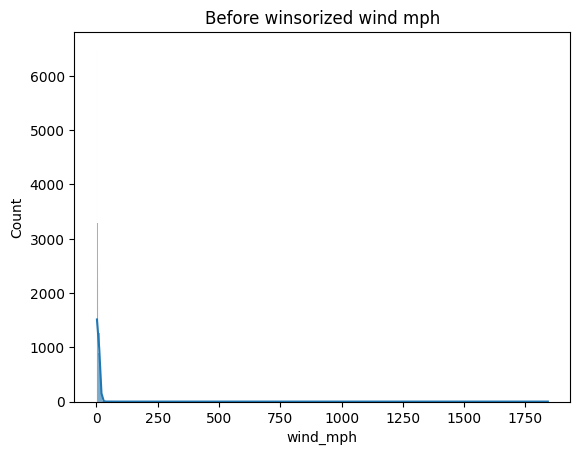

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(x=sorted_weather.wind_mph, kde=True)
plt.title("Before winsorized wind mph")
plt.show()

In [ ]:
# Using winsorization method to deal with outliers
# replace bottom 5% with its nearest bottom 5% value and replace top 5% with its nearest top 5% value
from scipy.stats.mstats import winsorize

winsorized_cols = ["wind_mph", "precip_mm", "cloud",
                   "visibility_km", "gust_mph", "moon_illumination"]

for col in winsorized_cols:
    all_numeric_weather[col] = winsorize(all_numeric_weather[col],(0.05,0.05))

In [ ]:
# Example after handling outliers in wind_mph variable
all_numeric_weather.wind_mph.describe()

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


count    48331.00000
mean         8.07652
std          4.75658
min          2.20000
25%          4.00000
50%          6.90000
75%         11.60000
max         18.30000
Name: wind_mph, dtype: float64

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


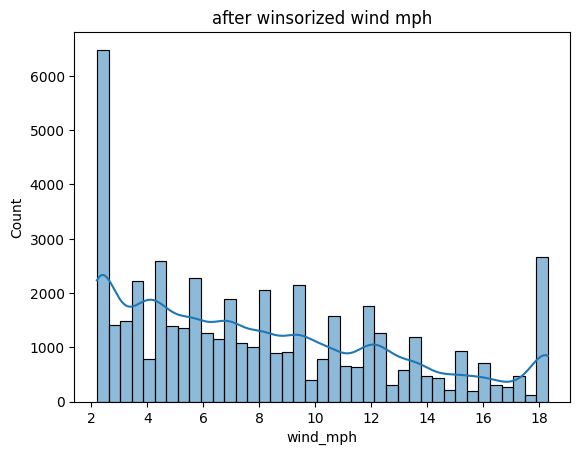

In [ ]:
sns.histplot(x=all_numeric_weather.wind_mph, kde=True)
plt.title("after winsorized wind mph")
plt.show()

### Handling Categorical Features / Feature Creation

In [ ]:
# Function to categorize uv index
def categorize_uv_index(uv_index):
    if 0 <= uv_index <= 2:
        return 'No_Protection_required'
    elif 3 <= uv_index <= 7:
        return 'Protection_required'
    else:
        return 'Extra_Protection_required'

all_numeric_weather['uv_category'] = all_numeric_weather['uv_index'].apply(categorize_uv_index)

In [ ]:
all_numeric_weather.head()

,country,location_name,latitude,longitude,last_updated_epoch,temperature_celsius,wind_mph,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,gust_mph,air_quality_gb-defra-index,moon_illumination,uv_category
0,Afghanistan,Kabul,34.52,69.18,1715849100,26.6,8.3,338,1012.0,0.00,24,30,10.0,7.0,9.5,1,55,Protection_required
195,Afghanistan,Kabul,34.52,69.18,1715868000,22.0,4.5,318,1014.0,0.03,41,89,10.0,5.0,5.3,1,55,Protection_required
390,Afghanistan,Kabul,34.52,69.18,1715961600,15.0,3.4,17,1017.0,0.69,75,77,9.0,1.0,4.7,1,64,No_Protection_required
583,Afghanistan,Kabul,34.52,69.18,1716042600,19.5,2.2,129,1010.0,0.00,46,15,10.0,1.0,6.7,1,73,No_Protection_required
776,Afghanistan,Kabul,34.52,69.18,1716127200,16.9,4.0,139,1010.0,0.17,52,75,9.0,4.0,5.3,1,81,Protection_required


#### Convert uv_index ranges from different numerical values to catgeorical values, so we can apply one-hot encoding later to this variable. This can reduce the demension of data.

In [ ]:
# Function to categorize air quality index
def categorize_air_quality(index):
    if index == 0:
        return "NA"
    elif 1 <= index <= 3:
        return 'Low'
    elif 4 <= index <= 6:
        return 'Moderate'
    elif 7 <= index <= 9:
        return 'High'
    else:
        return 'Very_High'  # For values above 9

all_numeric_weather['air_quality_category'] = all_numeric_weather['air_quality_gb-defra-index'].apply(categorize_air_quality)

In [ ]:
all_numeric_weather.head()

,country,location_name,latitude,longitude,last_updated_epoch,temperature_celsius,wind_mph,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,gust_mph,air_quality_gb-defra-index,moon_illumination,uv_category,air_quality_category
0,Afghanistan,Kabul,34.52,69.18,1715849100,26.6,8.3,338,1012.0,0.00,24,30,10.0,7.0,9.5,1,55,Protection_required,Low
195,Afghanistan,Kabul,34.52,69.18,1715868000,22.0,4.5,318,1014.0,0.03,41,89,10.0,5.0,5.3,1,55,Protection_required,Low
390,Afghanistan,Kabul,34.52,69.18,1715961600,15.0,3.4,17,1017.0,0.69,75,77,9.0,1.0,4.7,1,64,No_Protection_required,Low
583,Afghanistan,Kabul,34.52,69.18,1716042600,19.5,2.2,129,1010.0,0.00,46,15,10.0,1.0,6.7,1,73,No_Protection_required,Low
776,Afghanistan,Kabul,34.52,69.18,1716127200,16.9,4.0,139,1010.0,0.17,52,75,9.0,4.0,5.3,1,81,Protection_required,Low


#### Apply the same idea as converting uv_index to air_quality_gb-defra-index

In [ ]:
sorted_weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48331 entries, 0 to 11592
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     48331 non-null  object 
 1   location_name               48331 non-null  object 
 2   latitude                    48331 non-null  float64
 3   longitude                   48331 non-null  float64
 4   timezone                    48331 non-null  object 
 5   last_updated_epoch          48331 non-null  int64  
 6   last_updated                48331 non-null  object 
 7   temperature_celsius         48331 non-null  float64
 8   condition_text              48331 non-null  object 
 9   wind_mph                    48331 non-null  float64
 10  wind_degree                 48331 non-null  int64  
 11  pressure_mb                 48331 non-null  float64
 12  precip_mm                   48331 non-null  float64
 13  humidity                    48331 no

#### Handling catgeorical variables

In [ ]:
all_categorical_weather = sorted_weather.select_dtypes(include=['object']).copy()

In [ ]:
all_categorical_weather.head()

,country,location_name,timezone,last_updated,condition_text,sunrise,sunset,moonrise,moonset
0,Afghanistan,Kabul,Asia/Kabul,2024-05-16 13:15,Partly Cloudy,04:50 AM,06:50 PM,12:12 PM,01:11 AM
195,Afghanistan,Kabul,Asia/Kabul,2024-05-16 18:30,Patchy rain nearby,04:50 AM,06:50 PM,12:12 PM,01:11 AM
390,Afghanistan,Kabul,Asia/Kabul,2024-05-17 20:30,Patchy rain nearby,04:49 AM,06:51 PM,01:09 PM,01:37 AM
583,Afghanistan,Kabul,Asia/Kabul,2024-05-18 19:00,Clear,04:48 AM,06:51 PM,02:04 PM,02:00 AM
776,Afghanistan,Kabul,Asia/Kabul,2024-05-19 18:30,Patchy rain nearby,04:48 AM,06:52 PM,03:00 PM,02:22 AM


In [ ]:
from datetime import datetime

pattern = "%I:%M %p"

# convert these features to datetime type
time_cols = ["sunrise","sunset", "moonrise", "moonset"]

# A function to convert str to datetime
def convert_time(x):
    date = datetime(2025, 1, 18)
    try:
        time =  datetime.strptime(x, pattern).time()
        return datetime.combine(date, time)

    except ValueError:
        time =  datetime.strptime("12:00 AM", pattern).time()
        return datetime.combine(date, time)

# apply the convert_time()
for name in time_cols:
    all_categorical_weather[name] = all_categorical_weather[name].apply(convert_time)

In [ ]:
# find the difference between sunrise and sunset
all_categorical_weather["diff_sunrise_set"] = all_categorical_weather["sunset"] - all_categorical_weather["sunrise"]

# find the difference between mooneise and moonset
all_categorical_weather["diff_moonrise_set"] = all_categorical_weather["moonset"] - all_categorical_weather["moonrise"]

In [ ]:
# convert the difference calculated above to mins
all_categorical_weather["diff_sunrise_set"] = all_categorical_weather["diff_sunrise_set"].apply(lambda x: abs(x.total_seconds() / 60))
all_categorical_weather["diff_moonrise_set"] = all_categorical_weather["diff_moonrise_set"].apply(lambda x: abs(x.total_seconds() / 60))

In [ ]:
# convert the last_updated feature to datetime
pattern = "%Y-%m-%d %H:%M"

all_categorical_weather["last_updated"] = all_categorical_weather["last_updated"].apply(lambda x: datetime.strptime(x, pattern))

Since I have a lot of labels that we are going to predict, all weather events into 8 groups. The information could be found below

In [ ]:
weather_groups = {
    'Rain': [
        'Light rain', 'Moderate rain', 'Heavy rain', 'Light rain shower', 'Moderate rain shower',
        'Heavy rain at times', 'Torrential rain shower', 'Moderate or heavy rain with thunder',
        'Patchy light rain', 'Patchy rain nearby', 'Patchy rain possible', 'Patchy light rain shower',
        'Patchy rain in area with thunder', 'Moderate or heavy rain in area with thunder'
    ],
    'Snow': [
        'Light snow', 'Heavy snow', 'Moderate snow', 'Light snow showers', 'Heavy snow showers',
        'Blizzard', 'Patchy heavy snow', 'Patchy light snow', 'Patchy moderate snow',
        'Moderate or heavy snow showers', 'Moderate or heavy snow in area with thunder'
    ],
    'Sleet': [
        'Light sleet', 'Moderate or heavy sleet', 'Light sleet showers'
    ],
    'Drizzle': [
        'Light drizzle', 'Patchy light drizzle', 'Freezing drizzle'
    ],
    'Thunderstorms and Mixed': [
        'Thundery outbreaks in nearby', 'Thundery outbreaks possible', 'Moderate or heavy rain with thunder',
        'Patchy rain in area with thunder', 'Patchy light snow in area with thunder'
    ],
    'Clear/Sunny Weather': [
        'Clear', 'Sunny'
    ],
    'Cloudy Weather': [
        'Cloudy', 'Overcast', 'Partly Cloudy', 'Partly cloudy'
    ],
    'Mist/Fog': [
        'Mist', 'Fog', 'Freezing fog'
    ]
}

In [ ]:
# Function to assgin weather condition
def assign_topic(weather_condition):
    for topic, conditions in weather_groups.items():
        if weather_condition in conditions:
            return topic
    return 'Other'

# apply the assgin_topic()
all_categorical_weather['weather_condition'] = all_categorical_weather['condition_text'].apply(assign_topic)

In [ ]:
dropped_categorical_cols = ['country', 'location_name', "timezone", 'condition_text',  'sunrise', 'sunset', 'moonrise', 'moonset']
dropped_numerical_cols = ['last_updated_epoch', 'uv_index', 'air_quality_gb-defra-index']

numeric_weather_features = all_numeric_weather.drop(dropped_numerical_cols, axis=1)
categorical_weather_features = all_categorical_weather.drop(dropped_categorical_cols, axis=1)

In [ ]:
numeric_weather_features.head()

,country,location_name,latitude,longitude,temperature_celsius,wind_mph,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,gust_mph,moon_illumination,uv_category,air_quality_category
0,Afghanistan,Kabul,34.52,69.18,26.6,8.3,338,1012.0,0.00,24,30,10.0,9.5,55,Protection_required,Low
195,Afghanistan,Kabul,34.52,69.18,22.0,4.5,318,1014.0,0.03,41,89,10.0,5.3,55,Protection_required,Low
390,Afghanistan,Kabul,34.52,69.18,15.0,3.4,17,1017.0,0.69,75,77,9.0,4.7,64,No_Protection_required,Low
583,Afghanistan,Kabul,34.52,69.18,19.5,2.2,129,1010.0,0.00,46,15,10.0,6.7,73,No_Protection_required,Low
776,Afghanistan,Kabul,34.52,69.18,16.9,4.0,139,1010.0,0.17,52,75,9.0,5.3,81,Protection_required,Low


In [ ]:
categorical_weather_features.head()

,last_updated,diff_sunrise_set,diff_moonrise_set,weather_condition
0,2024-05-16 13:15:00,840.0,661.0,Cloudy Weather
195,2024-05-16 18:30:00,840.0,661.0,Rain
390,2024-05-17 20:30:00,842.0,692.0,Rain
583,2024-05-18 19:00:00,843.0,724.0,Clear/Sunny Weather
776,2024-05-19 18:30:00,844.0,758.0,Rain


In [ ]:
not_modeling_weather = pd.concat([numeric_weather_features, categorical_weather_features], axis=1).drop("weather_condition", axis=1)

In [ ]:
not_modeling_weather.head()

,country,location_name,latitude,longitude,temperature_celsius,wind_mph,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,gust_mph,moon_illumination,uv_category,air_quality_category,last_updated,diff_sunrise_set,diff_moonrise_set
0,Afghanistan,Kabul,34.52,69.18,26.6,8.3,338,1012.0,0.00,24,30,10.0,9.5,55,Protection_required,Low,2024-05-16 13:15:00,840.0,661.0
195,Afghanistan,Kabul,34.52,69.18,22.0,4.5,318,1014.0,0.03,41,89,10.0,5.3,55,Protection_required,Low,2024-05-16 18:30:00,840.0,661.0
390,Afghanistan,Kabul,34.52,69.18,15.0,3.4,17,1017.0,0.69,75,77,9.0,4.7,64,No_Protection_required,Low,2024-05-17 20:30:00,842.0,692.0
583,Afghanistan,Kabul,34.52,69.18,19.5,2.2,129,1010.0,0.00,46,15,10.0,6.7,73,No_Protection_required,Low,2024-05-18 19:00:00,843.0,724.0
776,Afghanistan,Kabul,34.52,69.18,16.9,4.0,139,1010.0,0.17,52,75,9.0,5.3,81,Protection_required,Low,2024-05-19 18:30:00,844.0,758.0


In [ ]:
not_modeling_weather.columns

Index(['country', 'location_name', 'latitude', 'longitude',
       'temperature_celsius', 'wind_mph', 'wind_degree', 'pressure_mb',
       'precip_mm', 'humidity', 'cloud', 'visibility_km', 'gust_mph',
       'moon_illumination', 'uv_category', 'air_quality_category',
       'last_updated', 'diff_sunrise_set', 'diff_moonrise_set'],
      dtype='object')

In [ ]:
not_modeling_weather = not_modeling_weather[['country', 'location_name', 'last_updated','latitude', 'longitude',
                                             'uv_category', 'air_quality_category','temperature_celsius',
                                             'wind_mph', 'wind_degree', 'pressure_mb',
                                           'precip_mm', 'humidity', 'cloud', 'visibility_km', 'gust_mph',
                                           'moon_illumination', 'diff_sunrise_set', 'diff_moonrise_set']]

In [ ]:
not_modeling_weather.head()

,country,location_name,last_updated,latitude,longitude,uv_category,air_quality_category,temperature_celsius,wind_mph,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,gust_mph,moon_illumination,diff_sunrise_set,diff_moonrise_set
0,Afghanistan,Kabul,2024-05-16 13:15:00,34.52,69.18,Protection_required,Low,26.6,8.3,338,1012.0,0.00,24,30,10.0,9.5,55,840.0,661.0
195,Afghanistan,Kabul,2024-05-16 18:30:00,34.52,69.18,Protection_required,Low,22.0,4.5,318,1014.0,0.03,41,89,10.0,5.3,55,840.0,661.0
390,Afghanistan,Kabul,2024-05-17 20:30:00,34.52,69.18,No_Protection_required,Low,15.0,3.4,17,1017.0,0.69,75,77,9.0,4.7,64,842.0,692.0
583,Afghanistan,Kabul,2024-05-18 19:00:00,34.52,69.18,No_Protection_required,Low,19.5,2.2,129,1010.0,0.00,46,15,10.0,6.7,73,843.0,724.0
776,Afghanistan,Kabul,2024-05-19 18:30:00,34.52,69.18,Protection_required,Low,16.9,4.0,139,1010.0,0.17,52,75,9.0,5.3,81,844.0,758.0


In [ ]:
print(not_modeling_weather.uv_category.unique())
print(not_modeling_weather.air_quality_category.unique())

['Protection_required' 'No_Protection_required'
 'Extra_Protection_required']
['Low' 'Moderate' 'High' 'Very_High']


In [ ]:
not_modeling_weather["uv_index"] = sorted_weather.uv_index
not_modeling_weather["air_quality_index"] = sorted_weather["air_quality_gb-defra-index"]

In [ ]:
not_modeling_weather.head()

,country,location_name,last_updated,latitude,longitude,uv_category,air_quality_category,temperature_celsius,wind_mph,wind_degree,...,precip_mm,humidity,cloud,visibility_km,gust_mph,moon_illumination,diff_sunrise_set,diff_moonrise_set,uv_index,air_quality_index
0,Afghanistan,Kabul,2024-05-16 13:15:00,34.52,69.18,Protection_required,Low,26.6,8.3,338,...,0.00,24,30,10.0,9.5,55,840.0,661.0,7.0,1
195,Afghanistan,Kabul,2024-05-16 18:30:00,34.52,69.18,Protection_required,Low,22.0,4.5,318,...,0.03,41,89,10.0,5.3,55,840.0,661.0,5.0,1
390,Afghanistan,Kabul,2024-05-17 20:30:00,34.52,69.18,No_Protection_required,Low,15.0,3.4,17,...,0.69,75,77,9.0,4.7,64,842.0,692.0,1.0,1
583,Afghanistan,Kabul,2024-05-18 19:00:00,34.52,69.18,No_Protection_required,Low,19.5,2.2,129,...,0.00,46,15,10.0,6.7,73,843.0,724.0,1.0,1
776,Afghanistan,Kabul,2024-05-19 18:30:00,34.52,69.18,Protection_required,Low,16.9,4.0,139,...,0.17,52,75,9.0,5.3,81,844.0,758.0,4.0,1


## Simple EDA

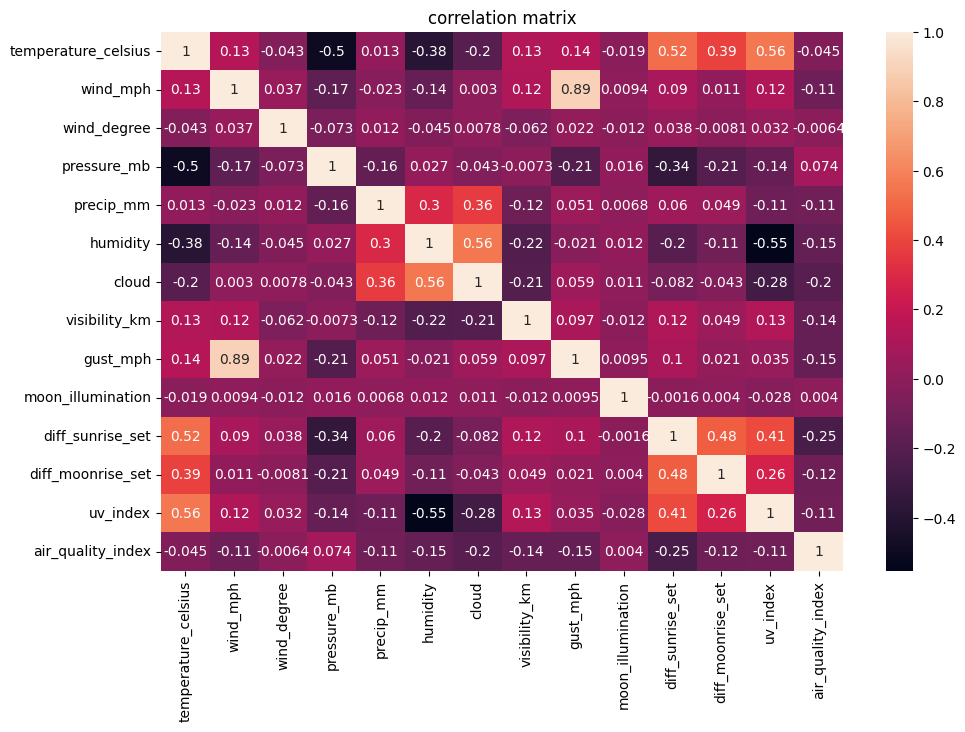

In [ ]:
cm = not_modeling_weather.iloc[:, 7:].corr()
plt.figure(figsize=(11, 7))
sns.heatmap(cm, annot=True)
plt.title("correlation matrix")
plt.show()

Most of variables are not corrleated. Starting from temperature, temperature is correlated with difference between sunrise and sunset, and uv_index. Humity is correlated with cloud. The difference between sunrise and sunset is correlated with difference between moonrise and moonset, and also uv_index.

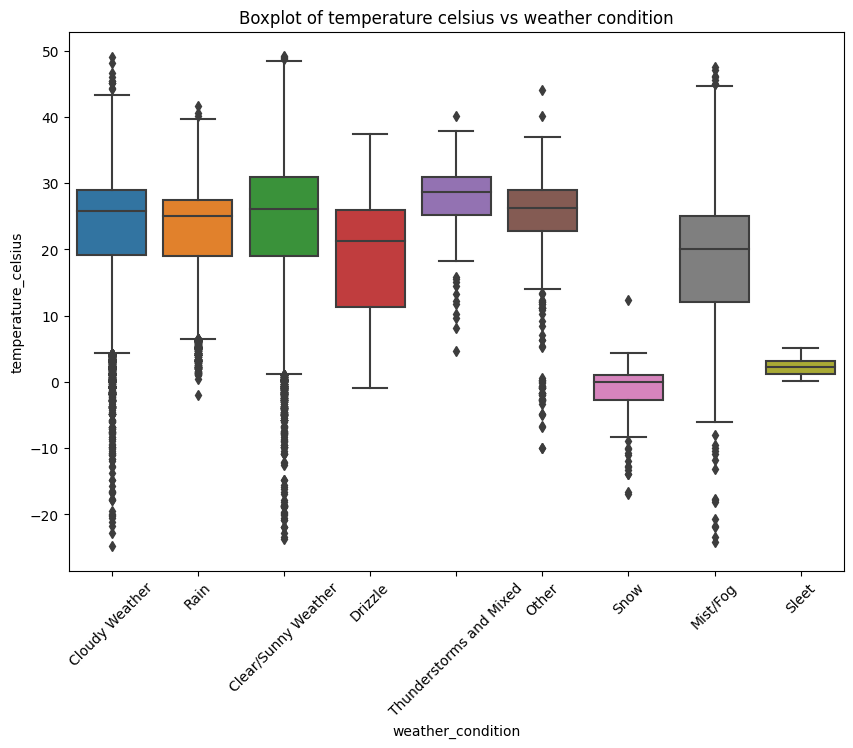

In [ ]:
plt.figure(figsize=(10, 7))
sns.boxplot(x=categorical_weather_features.weather_condition, y=not_modeling_weather.temperature_celsius)
plt.title("Boxplot of temperature celsius vs weather condition")
plt.xticks(rotation=45)
plt.show()

This boxplot shows the temperature distribution in each type of weather condition. The temperature of sunny and cloudy is irregular because they have a lot of negative outliers. This is because of different areas. Some areas are always in a cold temperature.

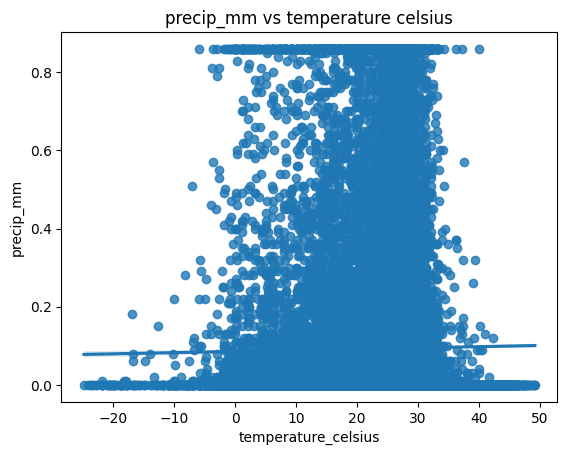

In [ ]:
sns.regplot(x="temperature_celsius", y="precip_mm", data=not_modeling_weather)
plt.title("precip_mm vs temperature celsius")
plt.show()

As the scatterplot shows, we can know correlation between temperature and Precipitation is weak. This may indcate they don't have any connection that higher temperature leads to higher measurement in precipitation

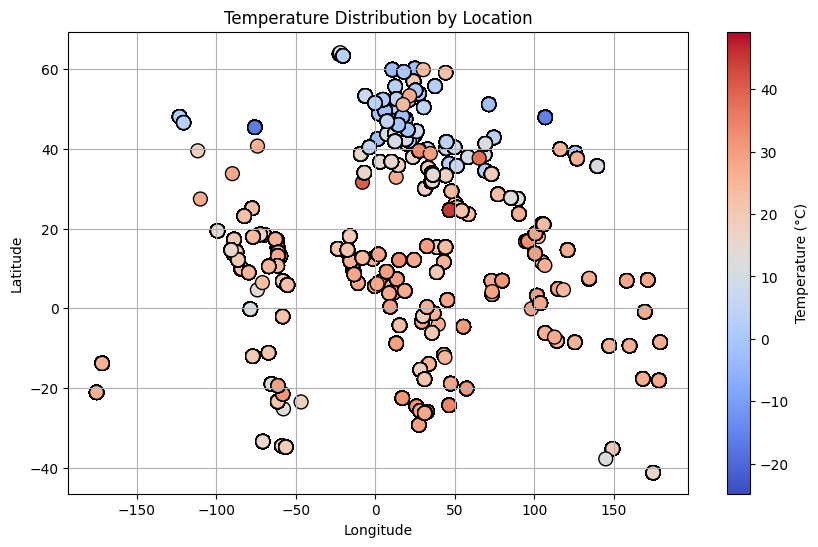

In [ ]:
# Plot scatterplot as a geometirc plot showing temperature across all locations
# running plotly can freeze my screen while using kaggle notebook

# Spatial Analysis: Analyze and visualize geographical patterns in the data.

plt.figure(figsize=(10, 6))
sc = plt.scatter(not_modeling_weather['longitude'], not_modeling_weather['latitude'],
                 c=not_modeling_weather['temperature_celsius'], cmap='coolwarm', s=100, edgecolor='k')
plt.colorbar(sc, label='Temperature (°C)')
plt.title('Temperature Distribution by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

As Latitude above 40, we can see there are a lot of places are under a cold weather.

In [ ]:
# Countries are under a cold weather
sampled_df_cold = not_modeling_weather[not_modeling_weather.latitude>40]
print(len(sampled_df_cold.country.unique()))
sampled_df_cold.country.unique()

55


array(['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan',
       'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria',
       'Bélgica', 'Canada', 'Croatia', 'Czech Republic', 'Denmark',
       'Estonia', 'Estonie', 'Finland', 'France', 'Georgia', 'Germany',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kazakhstan', 'Kosovo',
       'Kyrghyzstan', 'Latvia', 'Letonia', 'Liechtenstein', 'Lithuania',
       'Luxembourg', 'Macedonia', 'Monaco', 'Mongolia', 'Montenegro',
       'Netherlands', 'Norway', 'Poland', 'Polônia', 'Romania', 'Russia',
       'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland', 'Ukraine', 'United Kingdom',
       'United States of America', 'Uzbekistan', 'Vatican City', 'Польша'],
      dtype=object)

In [ ]:
# Countries are under a warm weather
sampled_df_warm = not_modeling_weather[not_modeling_weather.latitude<40]
print(len(sampled_df_warm.country.unique()))
sampled_df_warm.country.unique()

155


array(['Afghanistan', 'Algeria', 'Angola', 'Antigua and Barbuda',
       'Argentina', 'Australia', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Botswana',
       'Brazil', 'Brunei Darussalam', 'Burkina Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Cape Verde', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Costa Rica', 'Cuba', 'Cyprus', 'Democratic Republic of Congo',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia',
       'Fiji Islands', 'Gabon', 'Gambia', 'Ghana', 'Greece', 'Grenada',
       'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti',
       'Honduras', 'Inde', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel',
       'Jamaica', 'Japan', 'Jemen', 'Jordan', 'Kenya', 'Kiribati',
       'Komoren', 'Kuwait', "Lao People's Democratic Republic", 'Lebanon',
       'Lesotho', 'Liberia

In [ ]:
# calculate average temperature of each country
not_modeling_weather.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False)

country
Saudi Arabien               45.000000
Marrocos                    40.300000
Turkménistan                37.800000
Saudi Arabia                34.732389
Kuwait                      34.425703
                              ...    
Norway                       9.639516
Canada                       9.534146
United States of America     9.151639
Iceland                      6.378313
Mongolia                     3.591532
Name: temperature_celsius, Length: 210, dtype: float64

I found that the Saudi Arabien is the warmest counrty and the Mongolia is the coldest country

In [ ]:
# Environmental Impact: Analyze air quality and its correlation with various weather parameters.
sorted_weather.groupby("condition_text")["air_quality_gb-defra-index"].mean().sort_values(ascending=False)[[0, -1]]

<ipython-input-53-15f4f4887132>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_weather.groupby("condition_text")["air_quality_gb-defra-index"].mean().sort_values(ascending=False)[[0, -1]]


condition_text
Freezing drizzle    6.5
Blizzard            1.0
Name: air_quality_gb-defra-index, dtype: float64

Freezing drizzle has the worst air quality and Blizzard have the best air quality

## Modeling Dataset

In [ ]:
not_modeling_weather.columns

Index(['country', 'location_name', 'last_updated', 'latitude', 'longitude',
       'uv_category', 'air_quality_category', 'temperature_celsius',
       'wind_mph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'visibility_km', 'gust_mph', 'moon_illumination',
       'diff_sunrise_set', 'diff_moonrise_set', 'uv_index',
       'air_quality_index'],
      dtype='object')

Since this is a forecasting project, I cannot use current information to predict the label, as the goal is to predict future conditions based on historical data. Each row in the dataset represents the information corresponding to the label, rather than leveraging past information.

To address this, I need to replace the current values with aggregated historical data. For instance, if Kabul recorded 22°C on June 11, 2024, I would calculate the average temperature over the previous 10 days and use that value instead. This approach ensures the model relies on prior information to forecast future weather conditions accurately.

In [ ]:
# Calculate the rolling average of the last `n` days for specific columns in a DataFrame.
def last_ndays_average(n, df, colnames):
    loc_names = df['location_name'].unique()  # Ensure consistency with column name

    for colname in colnames:
        print(f"Calculating rolling average for {colname}")
        averages = []

        for loc in loc_names:
            # Filter data for the current location
            subset = df[df['location_name'] == loc].copy()

            subset[f"Last_{n}_days_average_{colname}"] = (
                subset[colname].rolling(window=n, min_periods=1).mean().shift(1).fillna(0)
            )

            averages.append(subset[f"Last_{n}_days_average_{colname}"])

        df[f"Last_{n}_days_average_{colname}"] = pd.concat(averages, axis=0)

In [ ]:
rolling_features = ['temperature_celsius', 'wind_mph', 'wind_degree',
                    'pressure_mb', 'precip_mm', 'humidity',
                    'cloud', 'visibility_km', 'gust_mph',
                    'moon_illumination','diff_sunrise_set', 'diff_moonrise_set',
                    'uv_index','air_quality_index']

last_ndays_average(5, not_modeling_weather, rolling_features)

Calculating rolling average for temperature_celsius
Calculating rolling average for wind_mph
Calculating rolling average for wind_degree
Calculating rolling average for pressure_mb
Calculating rolling average for precip_mm
Calculating rolling average for humidity
Calculating rolling average for cloud
Calculating rolling average for visibility_km
Calculating rolling average for gust_mph
Calculating rolling average for moon_illumination
Calculating rolling average for diff_sunrise_set
Calculating rolling average for diff_moonrise_set
Calculating rolling average for uv_index
Calculating rolling average for air_quality_index


In [ ]:
# An exmaple to show calculating rolling average for temperature_celsius
not_modeling_weather[["country", "location_name", "temperature_celsius", "Last_5_days_average_temperature_celsius"]].head()

,country,location_name,temperature_celsius,Last_5_days_average_temperature_celsius
0,Afghanistan,Kabul,26.6,0.000
195,Afghanistan,Kabul,22.0,26.600
390,Afghanistan,Kabul,15.0,24.300
583,Afghanistan,Kabul,19.5,21.200
776,Afghanistan,Kabul,16.9,20.775


In [ ]:
not_modeling_weather["uv_category"] = not_modeling_weather["Last_5_days_average_uv_index"].apply(categorize_uv_index)
not_modeling_weather["air_quality_category"] = not_modeling_weather["Last_5_days_average_air_quality_index"].apply(categorize_air_quality)

not_modeling_weather.head()

,country,location_name,last_updated,latitude,longitude,uv_category,air_quality_category,temperature_celsius,wind_mph,wind_degree,...,Last_5_days_average_precip_mm,Last_5_days_average_humidity,Last_5_days_average_cloud,Last_5_days_average_visibility_km,Last_5_days_average_gust_mph,Last_5_days_average_moon_illumination,Last_5_days_average_diff_sunrise_set,Last_5_days_average_diff_moonrise_set,Last_5_days_average_uv_index,Last_5_days_average_air_quality_index
0,Afghanistan,Kabul,2024-05-16 13:15:00,34.52,69.18,No_Protection_required,NA,26.6,8.3,338,...,0.000,0.000000,0.000000,0.000000,0.00,0.00,0.000000,0.000000,0.000000,0.0
195,Afghanistan,Kabul,2024-05-16 18:30:00,34.52,69.18,Protection_required,Low,22.0,4.5,318,...,0.000,24.000000,30.000000,10.000000,9.50,55.00,840.000000,661.000000,7.000000,1.0
390,Afghanistan,Kabul,2024-05-17 20:30:00,34.52,69.18,Protection_required,Low,15.0,3.4,17,...,0.015,32.500000,59.500000,10.000000,7.40,55.00,840.000000,661.000000,6.000000,1.0
583,Afghanistan,Kabul,2024-05-18 19:00:00,34.52,69.18,Protection_required,Low,19.5,2.2,129,...,0.240,46.666667,65.333333,9.666667,6.50,58.00,840.666667,671.333333,4.333333,1.0
776,Afghanistan,Kabul,2024-05-19 18:30:00,34.52,69.18,Protection_required,Low,16.9,4.0,139,...,0.180,46.500000,52.750000,9.750000,6.55,61.75,841.250000,684.500000,3.500000,1.0


In [ ]:
loc_names = not_modeling_weather['location_name'].unique()
for loc in loc_names:
    index = not_modeling_weather[not_modeling_weather.location_name == loc].index[0]
    not_modeling_weather.loc[index, "uv_category"] = "NA"

In [ ]:
not_modeling_weather.head()

,country,location_name,last_updated,latitude,longitude,uv_category,air_quality_category,temperature_celsius,wind_mph,wind_degree,...,Last_5_days_average_precip_mm,Last_5_days_average_humidity,Last_5_days_average_cloud,Last_5_days_average_visibility_km,Last_5_days_average_gust_mph,Last_5_days_average_moon_illumination,Last_5_days_average_diff_sunrise_set,Last_5_days_average_diff_moonrise_set,Last_5_days_average_uv_index,Last_5_days_average_air_quality_index
0,Afghanistan,Kabul,2024-05-16 13:15:00,34.52,69.18,NA,NA,26.6,8.3,338,...,0.000,0.000000,0.000000,0.000000,0.00,0.00,0.000000,0.000000,0.000000,0.0
195,Afghanistan,Kabul,2024-05-16 18:30:00,34.52,69.18,Protection_required,Low,22.0,4.5,318,...,0.000,24.000000,30.000000,10.000000,9.50,55.00,840.000000,661.000000,7.000000,1.0
390,Afghanistan,Kabul,2024-05-17 20:30:00,34.52,69.18,Protection_required,Low,15.0,3.4,17,...,0.015,32.500000,59.500000,10.000000,7.40,55.00,840.000000,661.000000,6.000000,1.0
583,Afghanistan,Kabul,2024-05-18 19:00:00,34.52,69.18,Protection_required,Low,19.5,2.2,129,...,0.240,46.666667,65.333333,9.666667,6.50,58.00,840.666667,671.333333,4.333333,1.0
776,Afghanistan,Kabul,2024-05-19 18:30:00,34.52,69.18,Protection_required,Low,16.9,4.0,139,...,0.180,46.500000,52.750000,9.750000,6.55,61.75,841.250000,684.500000,3.500000,1.0


In [ ]:
not_modeling_weather.columns

Index(['country', 'location_name', 'last_updated', 'latitude', 'longitude',
       'uv_category', 'air_quality_category', 'temperature_celsius',
       'wind_mph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'visibility_km', 'gust_mph', 'moon_illumination',
       'diff_sunrise_set', 'diff_moonrise_set', 'uv_index',
       'air_quality_index', 'Last_5_days_average_temperature_celsius',
       'Last_5_days_average_wind_mph', 'Last_5_days_average_wind_degree',
       'Last_5_days_average_pressure_mb', 'Last_5_days_average_precip_mm',
       'Last_5_days_average_humidity', 'Last_5_days_average_cloud',
       'Last_5_days_average_visibility_km', 'Last_5_days_average_gust_mph',
       'Last_5_days_average_moon_illumination',
       'Last_5_days_average_diff_sunrise_set',
       'Last_5_days_average_diff_moonrise_set', 'Last_5_days_average_uv_index',
       'Last_5_days_average_air_quality_index'],
      dtype='object')

In [ ]:
modeling_dataset = not_modeling_weather.drop(['country', 'location_name', 'temperature_celsius',
       'wind_mph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'visibility_km', 'gust_mph', 'moon_illumination',
       'diff_sunrise_set', 'diff_moonrise_set', 'uv_index',
       'air_quality_index'], axis=1).copy()

In [ ]:
modeling_dataset.isnull().sum()

last_updated                               0
latitude                                   0
longitude                                  0
uv_category                                0
air_quality_category                       0
Last_5_days_average_temperature_celsius    0
Last_5_days_average_wind_mph               0
Last_5_days_average_wind_degree            0
Last_5_days_average_pressure_mb            0
Last_5_days_average_precip_mm              0
Last_5_days_average_humidity               0
Last_5_days_average_cloud                  0
Last_5_days_average_visibility_km          0
Last_5_days_average_gust_mph               0
Last_5_days_average_moon_illumination      0
Last_5_days_average_diff_sunrise_set       0
Last_5_days_average_diff_moonrise_set      0
Last_5_days_average_uv_index               0
Last_5_days_average_air_quality_index      0
dtype: int64

In [ ]:
modeling_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48331 entries, 0 to 11592
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   last_updated                             48331 non-null  datetime64[ns]
 1   latitude                                 48331 non-null  float64       
 2   longitude                                48331 non-null  float64       
 3   uv_category                              48331 non-null  object        
 4   air_quality_category                     48331 non-null  object        
 5   Last_5_days_average_temperature_celsius  48331 non-null  float64       
 6   Last_5_days_average_wind_mph             48331 non-null  float64       
 7   Last_5_days_average_wind_degree          48331 non-null  float64       
 8   Last_5_days_average_pressure_mb          48331 non-null  float64       
 9   Last_5_days_average_precip_mm            483

In [ ]:
modeling_dataset = pd.get_dummies(modeling_dataset, dtype=float)

In [ ]:
modeling_dataset["weather_condition"] = categorical_weather_features["weather_condition"]

In [ ]:
modeling_dataset = modeling_dataset.sort_values("last_updated").reset_index(drop=True).drop(["last_updated",
                                                                                             "uv_category_NA",
                                                                                             "air_quality_category_NA",
                                                                                             "Last_5_days_average_uv_index",
                                                                                             "Last_5_days_average_air_quality_index"], axis=1)

In [ ]:
modeling_dataset.head()

,latitude,longitude,Last_5_days_average_temperature_celsius,Last_5_days_average_wind_mph,Last_5_days_average_wind_degree,Last_5_days_average_pressure_mb,Last_5_days_average_precip_mm,Last_5_days_average_humidity,Last_5_days_average_cloud,Last_5_days_average_visibility_km,...,Last_5_days_average_diff_sunrise_set,Last_5_days_average_diff_moonrise_set,uv_category_Extra_Protection_required,uv_category_No_Protection_required,uv_category_Protection_required,air_quality_category_High,air_quality_category_Low,air_quality_category_Moderate,air_quality_category_Very_High,weather_condition
0,46.60,-120.49,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Clear/Sunny Weather
1,14.10,-87.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cloudy Weather
2,14.62,-90.53,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Mist/Fog
3,9.97,-84.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Mist/Fog
4,19.43,-99.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Clear/Sunny Weather


In [ ]:
weather_mapping = {
    'Clear/Sunny Weather': 0,
    'Rain': 1,
    'Cloudy Weather': 2,
    'Mist/Fog': 3,
    'Other': 4,
    'Drizzle': 5,
    'Thunderstorms and Mixed': 6,
    'Snow': 7,
    'Sleet': 8
}

modeling_dataset['weather_condition'] = modeling_dataset['weather_condition'].map(weather_mapping)

In [ ]:
modeling_dataset.head()

,latitude,longitude,Last_5_days_average_temperature_celsius,Last_5_days_average_wind_mph,Last_5_days_average_wind_degree,Last_5_days_average_pressure_mb,Last_5_days_average_precip_mm,Last_5_days_average_humidity,Last_5_days_average_cloud,Last_5_days_average_visibility_km,...,Last_5_days_average_diff_sunrise_set,Last_5_days_average_diff_moonrise_set,uv_category_Extra_Protection_required,uv_category_No_Protection_required,uv_category_Protection_required,air_quality_category_High,air_quality_category_Low,air_quality_category_Moderate,air_quality_category_Very_High,weather_condition
0,46.60,-120.49,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,14.10,-87.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,14.62,-90.53,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,9.97,-84.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,19.43,-99.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
modeling_dataset = modeling_dataset[modeling_dataset.weather_condition != 8]

## Model Building

In [ ]:
modeling_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48301 entries, 0 to 48330
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   latitude                                 48301 non-null  float64
 1   longitude                                48301 non-null  float64
 2   Last_5_days_average_temperature_celsius  48301 non-null  float64
 3   Last_5_days_average_wind_mph             48301 non-null  float64
 4   Last_5_days_average_wind_degree          48301 non-null  float64
 5   Last_5_days_average_pressure_mb          48301 non-null  float64
 6   Last_5_days_average_precip_mm            48301 non-null  float64
 7   Last_5_days_average_humidity             48301 non-null  float64
 8   Last_5_days_average_cloud                48301 non-null  float64
 9   Last_5_days_average_visibility_km        48301 non-null  float64
 10  Last_5_days_average_gust_mph             48301 non-

In [ ]:
# standarize numerical features
from sklearn.preprocessing import StandardScaler

columns_to_scale = modeling_dataset.columns[2:13]

scaler = StandardScaler()

modeling_dataset[columns_to_scale] = scaler.fit_transform(modeling_dataset[columns_to_scale])

In [ ]:
modeling_dataset.shape

(48301, 22)

In [ ]:
train_index = 33695

X_train = modeling_dataset.iloc[:train_index, :].drop("weather_condition", axis=1)
y_train = modeling_dataset.iloc[:train_index]["weather_condition"]

X_test = modeling_dataset.iloc[train_index:, :].drop("weather_condition", axis=1)
y_test = modeling_dataset.iloc[train_index:]["weather_condition"]

In [ ]:
X_train.shape

(33695, 21)

In [ ]:
X_test.shape

(14606, 21)

In [ ]:
y_train.value_counts()

weather_condition
2    14510
0    11987
1     5482
3      911
4      417
5      274
6      102
7       12
Name: count, dtype: int64

In [ ]:
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
xgb_params = {
    "n_estimators": [5, 10, 50],
    "max_depth": [3, 5, 10],
    "learning_rate" : [0.1, 0.15, 0.2]
}

rfc_params = {
    "n_estimators": [5, 10, 50, 50],
    "max_depth": [3, 5, 10]
}

In [ ]:
max_no_improvement = 3
best_accuracy_so_far = 0

rf_accuracy = []
rf_params_list = []

max_pca_components = min(X_train.shape[1], 22)

for i in range(1, max_pca_components + 1):
    print(f"Testing {i} PCA components...")

    pca = PCA(n_components=i)
    X_train_pca = pca.fit_transform(X_train)

    pca_rf = RandomForestClassifier(random_state=42)
    pca_rf_grid = GridSearchCV(pca_rf, rfc_params, scoring='accuracy')

    pca_rf_grid.fit(X_train_pca, y_train)

     # Get the best accuracy for this iteration
    current_best_accuracy = pca_rf_grid.best_score_
    rf_params_list.append(pca_rf_grid.best_params_)
    rf_accuracy.append(current_best_accuracy)

    print(f"PCA Components: {i}, Best Accuracy: {current_best_accuracy:.4f}")

    if current_best_accuracy > best_accuracy_so_far:
        best_accuracy_so_far = current_best_accuracy
        no_improvement_count = 0
    else:
        no_improvement_count += 1

    if no_improvement_count >= max_no_improvement:
        print(f"No improvement for {max_no_improvement} consecutive iterations. Stopping early.")
        break

Testing 1 PCA components...
PCA Components: 1, Best Accuracy: 0.4581
Testing 2 PCA components...
PCA Components: 2, Best Accuracy: 0.5543
Testing 3 PCA components...
PCA Components: 3, Best Accuracy: 0.5725
Testing 4 PCA components...
PCA Components: 4, Best Accuracy: 0.5983
Testing 5 PCA components...
PCA Components: 5, Best Accuracy: 0.6085
Testing 6 PCA components...
PCA Components: 6, Best Accuracy: 0.6044
Testing 7 PCA components...
PCA Components: 7, Best Accuracy: 0.6023
Testing 8 PCA components...
PCA Components: 8, Best Accuracy: 0.5993
No improvement for 3 consecutive iterations. Stopping early.


In [ ]:
best_accuracy_so_far = 0

xgb_accuracy = []
xgb_params_list = []

for i in range(1, max_pca_components + 1):
    print(f"Testing {i} PCA components...")

    pca = PCA(n_components=i)
    X_train_pca = pca.fit_transform(X_train)

    pca_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    pca_xgb_grid = GridSearchCV(pca_xgb, xgb_params, scoring='accuracy')


    pca_xgb_grid.fit(X_train_pca, y_train)

    current_best_accuracy = pca_xgb_grid.best_score_
    xgb_params_list.append(pca_xgb_grid.best_params_)
    xgb_accuracy.append(current_best_accuracy)

    print(f"PCA Components: {i}, Best Accuracy: {current_best_accuracy:.4f}")


    if current_best_accuracy > best_accuracy_so_far:
        best_accuracy_so_far = current_best_accuracy
        no_improvement_count = 0  # Reset counter
    else:
        no_improvement_count += 1

    if no_improvement_count >= max_no_improvement:
        print(f"No improvement for {max_no_improvement} consecutive iterations. Stopping early.")
        break

Testing 1 PCA components...
PCA Components: 1, Best Accuracy: 0.4586
Testing 2 PCA components...
PCA Components: 2, Best Accuracy: 0.5700
Testing 3 PCA components...
PCA Components: 3, Best Accuracy: 0.5801
Testing 4 PCA components...
PCA Components: 4, Best Accuracy: 0.6018
Testing 5 PCA components...
PCA Components: 5, Best Accuracy: 0.6152
Testing 6 PCA components...
PCA Components: 6, Best Accuracy: 0.6152
Testing 7 PCA components...
PCA Components: 7, Best Accuracy: 0.6057
Testing 8 PCA components...
PCA Components: 8, Best Accuracy: 0.6042
Testing 9 PCA components...
PCA Components: 9, Best Accuracy: 0.6055
No improvement for 3 consecutive iterations. Stopping early.


In [ ]:
rf_params_list

[{'max_depth': 5, 'n_estimators': 10},
 {'max_depth': 10, 'n_estimators': 50},
 {'max_depth': 10, 'n_estimators': 50},
 {'max_depth': 10, 'n_estimators': 50},
 {'max_depth': 10, 'n_estimators': 50},
 {'max_depth': 10, 'n_estimators': 50},
 {'max_depth': 10, 'n_estimators': 50},
 {'max_depth': 10, 'n_estimators': 50}]

In [ ]:
xgb_params_list

[{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 5},
 {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 5},
 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50},
 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50},
 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50},
 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50},
 {'learning_rate': 0.15, 'max_depth': 5, 'n_estimators': 50},
 {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50},
 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50}]

In [ ]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

rf = RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)
xgb = XGBClassifier(learning_rate = 0.1, max_depth=10, n_estimators=50)

rf.fit(X_train_pca, y_train)
xgb.fit(X_train_pca, y_train)

rf_pred = rf.predict(X_test_pca)
xgb_pred = xgb.predict(X_test_pca)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(f"Random Forest accuracy: {accuracy_score(y_test, rf_pred)}")
print(f"XGB accuracy: {accuracy_score(y_test, xgb_pred)}")

Random Forest accuracy: 0.5739422155278653
XGB accuracy: 0.5675749691907436


In [ ]:
# random forest
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.63      0.62      0.62      4905
           1       0.57      0.14      0.23      1988
           2       0.54      0.79      0.64      6271
           3       0.62      0.13      0.22       961
           4       0.00      0.00      0.00       131
           5       0.00      0.00      0.00       132
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00       209

    accuracy                           0.57     14606
   macro avg       0.30      0.21      0.21     14606
weighted avg       0.56      0.57      0.53     14606



In [ ]:
# XGB
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.61      0.63      0.62      4905
           1       0.45      0.25      0.32      1988
           2       0.56      0.73      0.63      6271
           3       0.54      0.13      0.20       961
           4       0.00      0.00      0.00       131
           5       0.00      0.00      0.00       132
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00       209

    accuracy                           0.57     14606
   macro avg       0.27      0.22      0.22     14606
weighted avg       0.54      0.57      0.54     14606



In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier

In [ ]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ("rf", RandomForestClassifier(max_depth=10, n_estimators=50)),
    ("xgb", XGBClassifier(learning_rate=0.1, max_depth=10, n_estimators=50)),
]

stacking_model = StackingClassifier(estimators=estimators, passthrough=False)
stacking_model.fit(X_train_pca, y_train)

stacking_pred = stacking_model.predict(X_test_pca)
print(f"Stacking model accuracy: {accuracy_score(stacking_pred, y_test)}")

Stacking model accuracy: 0.5768862111461044


In [ ]:
# stacking model
print(classification_report(y_test, stacking_pred))

              precision    recall  f1-score   support

           0       0.65      0.61      0.63      4905
           1       0.53      0.20      0.29      1988
           2       0.55      0.78      0.64      6271
           3       0.55      0.13      0.21       961
           4       0.00      0.00      0.00       131
           5       0.00      0.00      0.00       132
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00       209

    accuracy                           0.58     14606
   macro avg       0.28      0.22      0.22     14606
weighted avg       0.56      0.58      0.54     14606

